# Hyperparameter Tuning: Grid Search and Random Search

## Overview

Hyperparameters are model settings fixed before training — unlike parameters (weights, coefficients), they are not learned from data. Tuning finds the hyperparameter values that minimise CV error on the training set.

**Tuning strategies:**

| Strategy | How it works | When to use |
|---|---|---|
| **Grid search** | Exhaustive evaluation of all combinations | ≤ 2 hyperparameters; small grids |
| **Random search** | Random samples from the hyperparameter space | ≥ 3 hyperparameters; large spaces |
| **Latin hypercube** | Space-filling design; better coverage than random | When budget is fixed and coverage matters |
| **Bayesian optimisation** | Learns which regions to explore next | Very expensive models; not covered here |

**Key insight (Bergstra & Bengio 2012):** Random search outperforms grid search for high-dimensional hyperparameter spaces because any given parameter is unlikely to be the most important one. With a fixed budget, random search covers the space better than a regular grid.

**The tuning-evaluation split:** Hyperparameter tuning uses cross-validation on the training set. The test set is never involved in tuning. For a rigorous unbiased performance estimate after tuning, use nested CV — see `nested_cv.ipynb`.

---

## Setup

In [1]:
library(tidyverse)
library(ggplot2)
library(rsample)
library(recipes)
library(parsnip)
library(workflows)
library(tune)        # tune_grid(), tune_bayes()
library(dials)       # hyperparameter ranges
library(yardstick)
library(patchwork)

set.seed(42)

n <- 600
tune_data <- tibble(
  nitrate     = rnorm(n, 3, 1.2),
  water_qual  = rnorm(n, 6, 1.5),
  distance_km = rexp(n, 0.4),
  elevation   = rnorm(n, 200, 80),
  slope_pct   = abs(rnorm(n, 10, 5)),
  present     = factor(rbinom(n, 1,
                   plogis(-1 + 0.6*water_qual - 0.7*nitrate - 0.2*distance_km)),
                   levels=c(0,1), labels=c("absent","present"))
)

init_split <- rsample::initial_split(tune_data, prop=0.80, strata=present)
train_data <- rsample::training(init_split)
test_data  <- rsample::testing(init_split)
cv_folds   <- rsample::vfold_cv(train_data, v=5, strata=present)

# Base recipe
rec <- recipe(present ~ nitrate + water_qual + distance_km + elevation + slope_pct,
              data=train_data) %>%
  step_normalize(all_numeric_predictors())

Warning message:
"package 'tidyverse' was built under R version 4.4.3"
Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'purrr' was built under R version 4.4.3"
Warning message:
"package 'dplyr' was built under R version 4.4.3"
Warning message:
"package 'stringr' was built under R version 4.4.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'rsample' was built under R version 4.4.3"
Warning message:
"package 'recipes' was built under R version 4.

---

## Grid Search

In [2]:
# Random forest: tune mtry and min_n
rf_spec_tune <- rand_forest(
  mode  = "classification",
  trees = 500,
  mtry  = tune(),    # tune() marks this as a tuning parameter
  min_n = tune()     # minimum node size
) %>%
  set_engine("ranger", seed=42)

wf_tune <- workflow() %>% add_recipe(rec) %>% add_model(rf_spec_tune)

# ── Regular (exhaustive) grid ─────────────────────────────────────────────────
grid_regular <- dials::grid_regular(
  mtry(range=c(1, 5)),
  min_n(range=c(2, 20)),
  levels=c(5, 4)   # 5 mtry × 4 min_n = 20 combinations
)
cat(sprintf("Grid size: %d combinations\n", nrow(grid_regular)))
print(grid_regular)

# Run grid search
grid_results <- tune::tune_grid(
  wf_tune,
  resamples = cv_folds,
  grid      = grid_regular,
  metrics   = metric_set(roc_auc),
  control   = control_grid(verbose=FALSE)
)

# Best hyperparameters
show_best(grid_results, metric="roc_auc", n=5)
best_grid <- select_best(grid_results, metric="roc_auc")
cat(sprintf("\nBest: mtry=%d, min_n=%d\n", best_grid$mtry, best_grid$min_n))

Grid size: 20 combinations
# A tibble: 20 × 2
    mtry min_n
   <int> <int>
 1     1     2
 2     2     2
 3     3     2
 4     4     2
 5     5     2
 6     1     8
 7     2     8
 8     3     8
 9     4     8
10     5     8
11     1    14
12     2    14
13     3    14
14     4    14
15     5    14
16     1    20
17     2    20
18     3    20
19     4    20
20     5    20


mtry,min_n,.metric,.estimator,mean,n,std_err,.config
<int>,<int>,<chr>,<chr>,<dbl>,<int>,<dbl>,<chr>
1,20,roc_auc,binary,0.7724632,5,0.01283274,pre0_mod04_post0
1,14,roc_auc,binary,0.7695830,5,0.01268833,pre0_mod03_post0
1,8,roc_auc,binary,0.7671642,5,0.01074069,pre0_mod02_post0
3,20,roc_auc,binary,0.7666548,5,0.01120630,pre0_mod12_post0
2,20,roc_auc,binary,0.7666495,5,0.01147707,pre0_mod08_post0



Best: mtry=1, min_n=20


---

## Random Search

In [3]:
# XGBoost: larger hyperparameter space — random search preferred
xgb_spec_tune <- boost_tree(
  mode            = "classification",
  trees           = 300,
  tree_depth      = tune(),
  learn_rate      = tune(),
  mtry            = tune(),
  min_n           = tune(),
  loss_reduction  = tune()
) %>%
  set_engine("xgboost", seed=42)

wf_xgb <- workflow() %>% add_recipe(rec) %>% add_model(xgb_spec_tune)

# Latin hypercube design: better coverage than pure random
grid_random <- dials::grid_latin_hypercube(
  tree_depth(),
  learn_rate(),
  mtry(range=c(1, 5)),
  min_n(),
  loss_reduction(),
  size = 30   # 30 random combinations
)
cat(sprintf("Random grid: %d combinations (vs. exhaustive grid of %d)\n",
            nrow(grid_random),
            prod(c(5, 5, 5, 5, 5))))

random_results <- tune::tune_grid(
  wf_xgb,
  resamples = cv_folds,
  grid      = grid_random,
  metrics   = metric_set(roc_auc),
  control   = control_grid(verbose=FALSE)
)

show_best(random_results, metric="roc_auc", n=5)
best_xgb <- select_best(random_results, metric="roc_auc")

Warning message:
"`grid_latin_hypercube()` was deprecated in dials 1.3.0.
ℹ Please use `grid_space_filling()` instead."


Random grid: 30 combinations (vs. exhaustive grid of 3125)


mtry,min_n,tree_depth,learn_rate,loss_reduction,.metric,.estimator,mean,n,std_err,.config
<int>,<int>,<int>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<int>,<dbl>,<chr>
3,8,8,1.508085e-06,9.718524e-07,roc_auc,binary,0.7722822,5,0.008611631,pre0_mod13_post0
1,4,4,2.549338e-02,1.330216e-02,roc_auc,binary,0.7691713,5,0.017158528,pre0_mod01_post0
2,5,14,1.099603e-02,5.071430e-08,roc_auc,binary,0.7688660,5,0.015966952,pre0_mod05_post0
4,11,10,1.360023e-07,2.425932e-04,roc_auc,binary,0.7617702,5,0.014044974,pre0_mod20_post0
2,18,6,3.282801e-06,2.636322e-06,roc_auc,binary,0.7611943,5,0.013985347,pre0_mod06_post0


---

## Visualising the Tuning Landscape

`geom_smooth()` using formula = 'y ~ x'


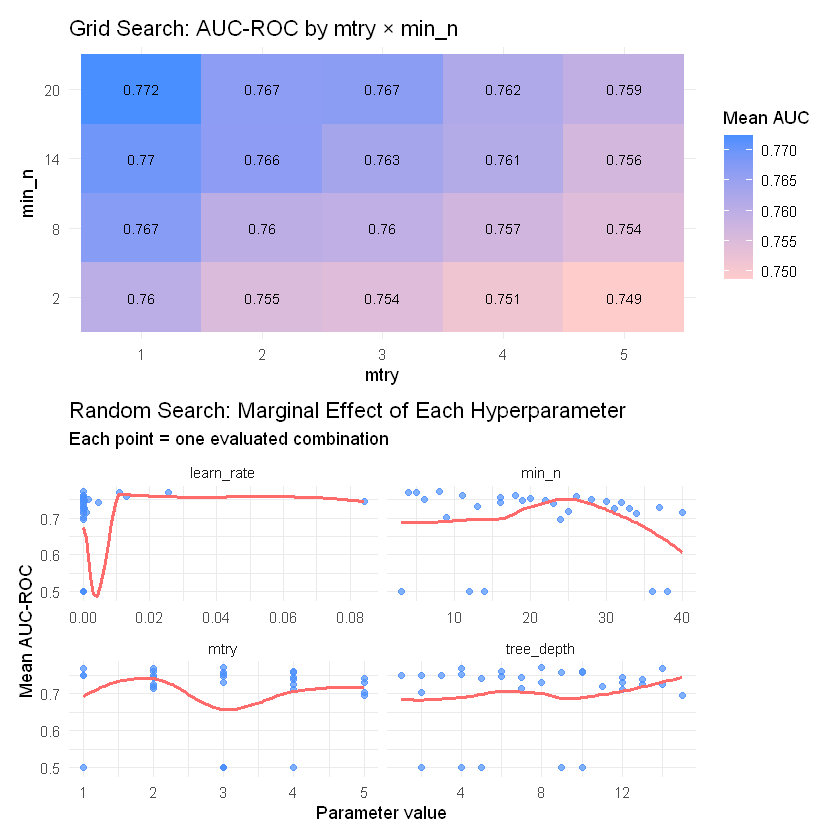

In [4]:
# ── Grid search: heatmap of AUC by mtry × min_n ──────────────────────────────
p_grid <- collect_metrics(grid_results) %>%
  filter(.metric=="roc_auc") %>%
  ggplot(aes(x=factor(mtry), y=factor(min_n), fill=mean)) +
  geom_tile() +
  geom_text(aes(label=round(mean,3)), size=3) +
  scale_fill_gradient(low="#ffcccc", high="#4a8fff") +
  labs(title="Grid Search: AUC-ROC by mtry × min_n",
       x="mtry", y="min_n", fill="Mean AUC") +
  theme_minimal()

# ── Random search: marginal effect plots ──────────────────────────────────────
p_rand <- collect_metrics(random_results) %>%
  filter(.metric=="roc_auc") %>%
  pivot_longer(c(tree_depth, learn_rate, mtry, min_n),
               names_to="param", values_to="value") %>%
  ggplot(aes(x=value, y=mean)) +
  geom_point(color="#4a8fff", alpha=0.7) +
  geom_smooth(color="#ff6b6b", se=FALSE, method="loess", span=0.8) +
  facet_wrap(~param, scales="free_x", ncol=2) +
  labs(title="Random Search: Marginal Effect of Each Hyperparameter",
       subtitle="Each point = one evaluated combination",
       x="Parameter value", y="Mean AUC-ROC") +
  theme_minimal()

(p_grid / p_rand)

---

## Finalise and Evaluate on Test Set

In [5]:
# 1-SE rule: select simplest model within 1 SE of the best
# Prefer simpler models when performance difference is within noise
best_1se <- select_by_one_std_err(grid_results, metric="roc_auc",
                                   desc(min_n))   # prefer larger min_n (simpler)

cat("Best model (max AUC):")
print(best_grid)
cat("\n1-SE rule (simpler model):")
print(best_1se)

# Finalise workflow: fix hyperparameters and refit on full training set
final_wf <- finalize_workflow(wf_tune, best_1se)
final_fit <- last_fit(final_wf, split=init_split,
                      metrics=metric_set(roc_auc, accuracy, f_meas))

cat("\nTest set performance (evaluated once):\n")
collect_metrics(final_fit) %>%
  mutate(.estimate=round(.estimate, 4)) %>%
  print()
# last_fit() refits on the full training set and evaluates on the test set
# This is the final, unbiased performance estimate

Best model (max AUC):# A tibble: 1 × 3
   mtry min_n .config         
  <int> <int> <chr>           
1     1    20 pre0_mod04_post0

1-SE rule (simpler model):# A tibble: 1 × 3
   mtry min_n .config         
  <int> <int> <chr>           
1     1    20 pre0_mod04_post0

Test set performance (evaluated once):
# A tibble: 3 × 4
  .metric  .estimator .estimate .config        
  <chr>    <chr>          <dbl> <chr>          
1 accuracy binary         0.727 pre0_mod0_post0
2 f_meas   binary         0.732 pre0_mod0_post0
3 roc_auc  binary         0.799 pre0_mod0_post0


---

## Common Pitfalls

**1. Tuning hyperparameters using the test set**  
Any use of the test set to inform a modelling decision — including hyperparameter choice — contaminates it. After selecting hyperparameters via CV on the training set, `last_fit()` evaluates on the test set exactly once. Do not iterate based on test set results.

**2. Using exhaustive grid search for ≥ 3 parameters**  
A 5-level grid over 5 parameters is 5⁵ = 3125 combinations. At 5-fold CV, that is 15,625 model fits. Random search or Latin hypercube sampling with 30–100 candidates achieves similar or better results in a fraction of the computation because most parameters are not the most important one.

**3. Reporting CV performance from the tuning step as the final model performance**  
The CV AUC used to select hyperparameters is optimistically biased — the hyperparameters were chosen to maximise it. This is the motivation for nested CV. Always use `last_fit()` on the held-out test set, or use nested CV, for the reported performance.

**4. Not using the 1-SE rule when appropriate**  
The best hyperparameters by mean CV metric may differ from a simpler model by much less than 1 SE. The 1-SE rule (`select_by_one_std_err()`) selects the simplest model within sampling noise of the best — it reduces complexity and overfitting risk at essentially no cost in expected performance.

**5. Fixing `trees` during tuning for tree ensembles**  
For XGBoost and LightGBM, `nrounds` (number of trees) should be determined by early stopping, not fixed in advance. Fix a maximum and use early stopping on a validation fold inside each CV fold. Fixing too few trees underestimates potential; fixing too many risks overfitting without stopping.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*